In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.impute import KNNImputer


In [2]:
# Carregar o dataset
df = pd.read_csv('Housing.csv')


In [3]:
print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [4]:
# Verificar valores ausentes e porcentagem
print("Valores ausentes")
missing_values = df.isnull().sum()
print(missing_values)
print("Porcentagem dos valores ausentes")
missing_percentage = (missing_values / len(df)) * 100
print(missing_percentage)


Valores ausentes
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
Porcentagem dos valores ausentes
price               0.0
area                0.0
bedrooms            0.0
bathrooms           0.0
stories             0.0
mainroad            0.0
guestroom           0.0
basement            0.0
hotwaterheating     0.0
airconditioning     0.0
parking             0.0
prefarea            0.0
furnishingstatus    0.0
dtype: float64


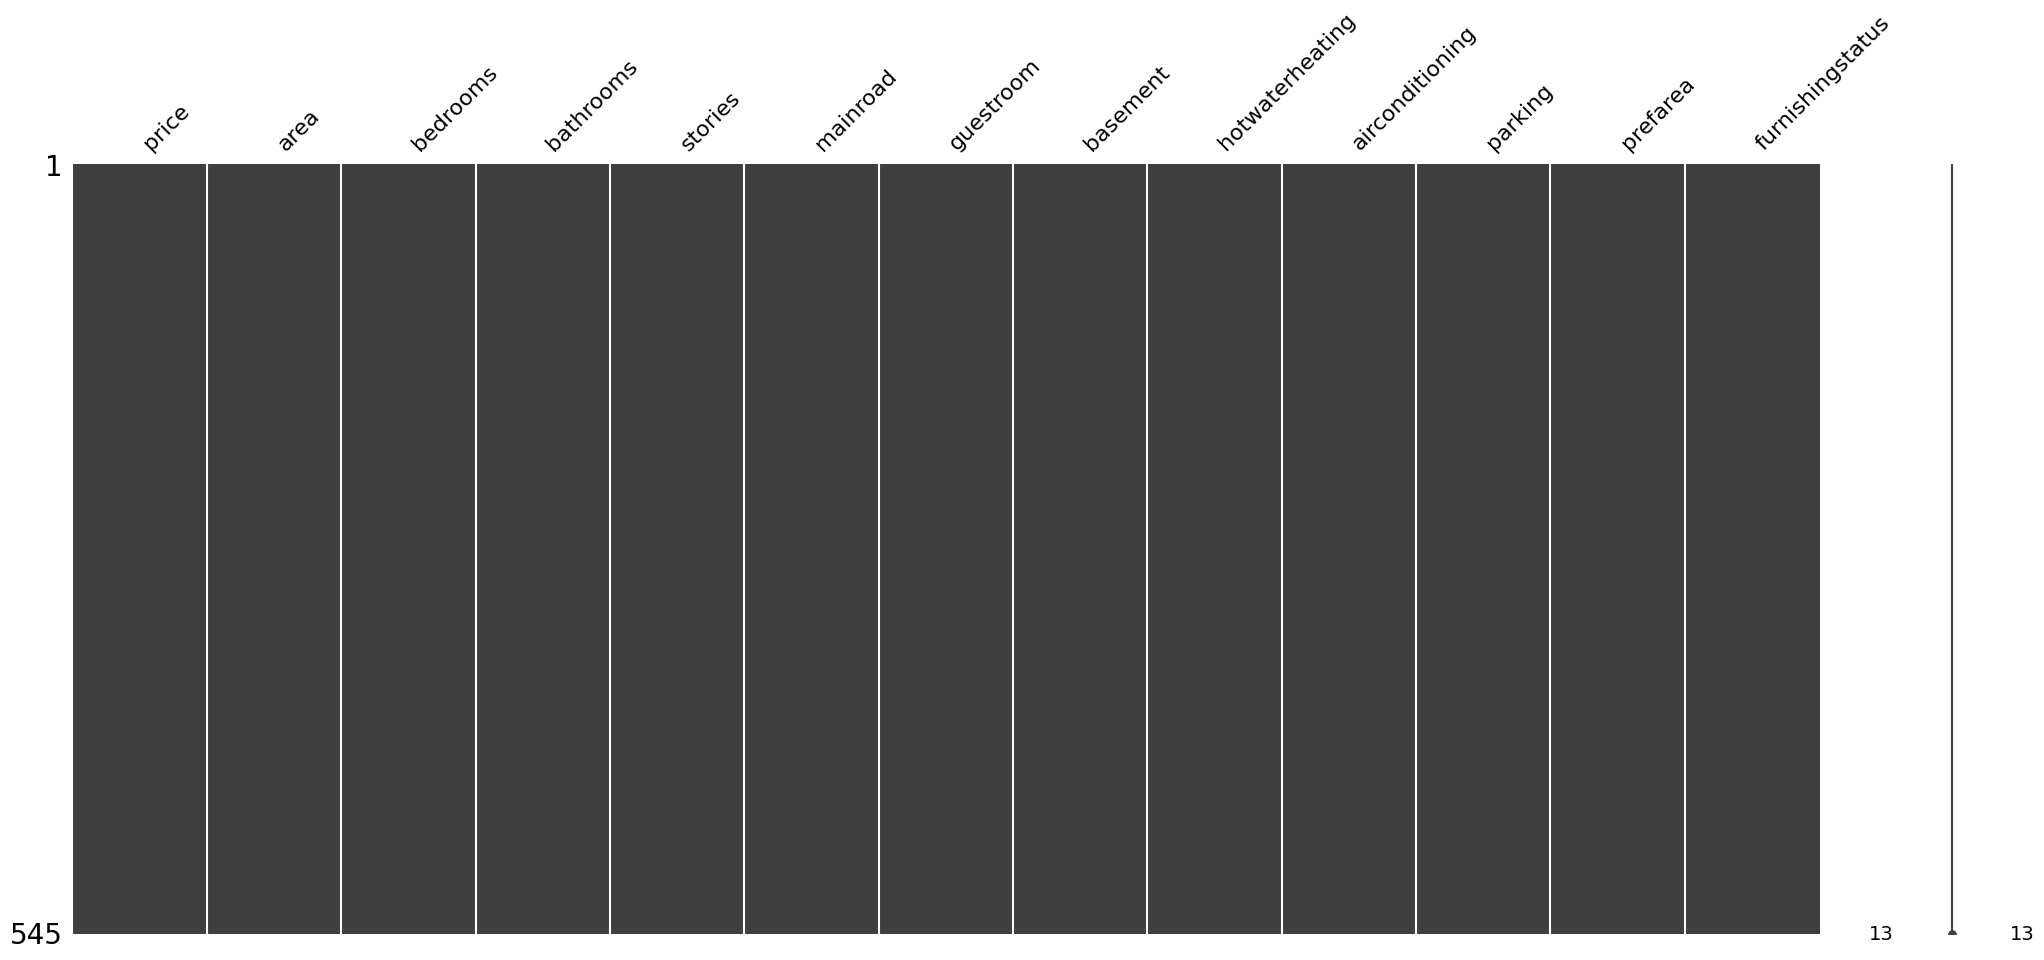

In [5]:
# Visualizar padrões de valores ausentes
msno.matrix(df)
plt.show()

In [6]:
df.isna().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [7]:
#Estrategia 1
#Remover os valore ausentes
df_dropna = df.dropna()
print(f"\nLinhas após remoção: {len(df_dropna)} (antes: {len(df)})")


Linhas após remoção: 545 (antes: 545)


In [8]:
#Estrategia 2
df_mean = df.copy()
numeric_cols = df_mean.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    df_mean[col].fillna(df_mean[col].mean(), inplace=True)

df_median = df.copy()
for col in numeric_cols:
    df_median[col].fillna(df_median[col].median(), inplace=True)

/tmp/ipython-input-372647319.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mean[col].fillna(df_mean[col].mean(), inplace=True)
/tmp/ipython-input-372647319.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [9]:
#Estrategia 3
imputer = KNNImputer(n_neighbors=5)
df_knn = df.copy()
df_knn[numeric_cols] = imputer.fit_transform(df_knn[numeric_cols])

In [10]:
print("\nComparando quantidade de valores ausentes após imputação:")
print("Original:", df.isnull().sum().sum())
print("Média:", df_mean.isnull().sum().sum())
print("Mediana:", df_median.isnull().sum().sum())
print("KNN:", df_knn.isnull().sum().sum())


Comparando quantidade de valores ausentes após imputação:
Original: 0
Média: 0
Mediana: 0
KNN: 0


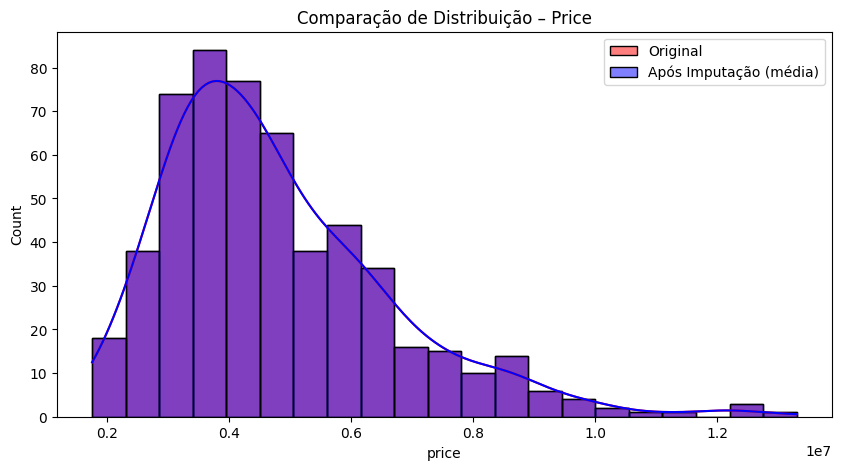

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(df['price'], kde=True, color='red', label='Original')
sns.histplot(df_mean['price'], kde=True, color='blue', label='Após Imputação (média)')
plt.legend()
plt.title('Comparação de Distribuição – Price')
plt.show()